# 🧠 Fine-tuning LoRA com YAML e Trainer — Vitalia

Este notebook treina um modelo **GPT-2 pequeno em português** (`pierreguillou/gpt2-small-portuguese`) com **LoRA** para tarefas de saúde e bem-estar, utilizando o `Trainer` do Hugging Face.

---

## 🎯 Objetivos desta versão

1. **Usar CUDA automaticamente** se uma GPU NVIDIA estiver disponível; caso contrário, cair para CPU sem quebrar o código.
2. **Salvar um checkpoint LoRA por época** (`epoca_1`, `epoca_2`, …) para permitir comparações posteriores.
3. **Analisar as curvas de perda, perplexidade e ganho acumulado** para justificar a escolha das épocas.
4. **Comparar três perfis** (`pior`, `bom`, `melhor`) escolhidos com base nas métricas — todos do **mesmo treino**.

---

## 🖥️ Sobre o uso de CUDA

O notebook detecta automaticamente o dispositivo disponível:

| Cenário | `device` | `dtype` do modelo | `fp16` no Trainer | Velocidade esperada |
| :--- | :--- | :--- | :--- | :--- |
| **GPU NVIDIA com CUDA** | `cuda` | `float16` | `True` | Minutos |
| **Apenas CPU** | `cpu` | `float32` | `False` | Horas |

**Requisitos para CUDA:**
- Driver NVIDIA atualizado (verifique com `nvidia-smi`).
- PyTorch instalado com suporte CUDA (ex: `uv pip install torch --torch-backend=auto`).
- GPU com pelo menos **4 GB de VRAM** para o GPT-2 small + LoRA.

## 1️⃣ Carregamento do `config.yaml`

A configuração centraliza **todos os hiperparâmetros**. Abaixo, a explicação de cada um e o impacto no treino:

### 🔧 Parâmetros de treino

| Parâmetro | Valor padrão | Descrição | Impacto |
| :--- | :---: | :--- | :--- |
| `epochs` | `10` | Número máximo de épocas. | Mais épocas podem melhorar, mas com early stopping o treino para sozinho se não houver progresso. |
| `learning_rate` | `1e-4` | Tamanho do passo do otimizador AdamW. | `1e-4` é um equilíbrio seguro para LoRA; valores maiores oscilam, menores demoram. |
| `batch_size` | `4` | Exemplos processados por lote. | `4` funciona bem em GPU; em CPU, use `2` para economizar memória. |
| `max_length` | `256` | Número máximo de tokens por exemplo. | `256` captura a resposta inteira sem truncar. |
| `weight_decay` | `0.01` | Regularização L2 aplicada aos pesos. | Penaliza pesos grandes, evitando overfitting. |
| `label_smoothing` | `0.0` | Suavização de rótulos na CrossEntropy. | **Deve ser 0.0** para replicar a perda do treino manual original. |

### 🧩 Parâmetros do LoRA

| Parâmetro | Valor padrão | Descrição | Impacto |
| :--- | :---: | :--- | :--- |
| `lora_r` | `4` | Rank das matrizes de baixa dimensão. | Baixo rank → menos parâmetros treináveis → menos overfitting em bases pequenas. |
| `lora_alpha` | `8` | Fator de escala do adaptador. | Geralmente `2×r`; equilibra a influência do adaptador sobre o modelo base. |
| `lora_dropout` | `0.1` | Dropout aplicado nas matrizes LoRA. | Adiciona regularização extra, reduzindo overfitting. |
| `lora_target_modules` | `['c_attn']` | Camadas onde LoRA será aplicado. | No GPT-2, `c_attn` corresponde às camadas de atenção (Conv1D). |

### 📂 Dados e saída

| Parâmetro | Valor padrão | Descrição |
| :--- | :---: | :--- |
| `data_path` | `..//saude.jsonl` | Caminho do dataset JSONL (relativo ao notebook). |
| `validation_split` | `0.20` | Fração dos dados reservada para validação (240 exemplos). |
| `seed` | `42` | Semente para reprodutibilidade (shuffle, pesos, dropout). |
| `output_dir` | `modelo_lora_trainer` | Pasta onde o adaptador LoRA final será salvo. |

### 🎨 Parâmetros de geração (inferência)

| Parâmetro | Valor padrão | Descrição |
| :--- | :---: | :--- |
| `max_new_tokens` | `70` | Número máximo de tokens gerados. |
| `do_sample` | `false` | Modo determinístico (guloso) — evita alucinações. |
| `num_beams` | `4` | Beam Search: explora 4 caminhos simultâneos. |
| `repetition_penalty` | `2.2` | Penaliza tokens já gerados (evita loops). |
| `no_repeat_ngram_size` | `4` | Impede repetição de 4-gramas. |

### ⏹️ Early Stopping

| Parâmetro | Valor padrão | Descrição |
| :--- | :---: | :--- |
| `early_stopping_patience` | `3` | Interrompe após 3 épocas sem melhora na `eval_loss`. |
| `early_stopping_threshold` | `0.001` | Melhora mínima exigida (1e-3) para considerar progresso. |

### 📊 Comparação de épocas

| Chave | Época | Justificativa |
| :--- | :---: | :--- |
| `pior` | `1` | Underfitting severo (val_loss 2.807). |
| `bom` | `5` | Ponto de equilíbrio: 94% do ganho total já obtido. |
| `melhor` | `10` | Menor val_loss observada (2.385), sem overfitting. |

In [1]:
import yaml
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json, random, math, time, re, os
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    Trainer, TrainingArguments, TrainerCallback, EarlyStoppingCallback
)
from datasets import Dataset
from peft import LoraConfig, get_peft_model, PeftModel

# --- Carrega o config.yaml do diretório pai ---
with open('..\\config.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

# --- Extrai parâmetros (com defaults seguros) ---
EPOCAS               = config['epochs']
TAXA_APRENDIZADO     = config['learning_rate']
TAMANHO_LOTE         = config['batch_size']
MAX_LENGTH           = config['max_length']
WEIGHT_DECAY         = config['weight_decay']
LABEL_SMOOTHING      = config.get('label_smoothing', 0.0)

LORA_R               = config['lora_r']
LORA_ALPHA           = config['lora_alpha']
LORA_DROPOUT         = config['lora_dropout']
LORA_TARGET          = config['lora_target_modules']

CAMINHO_BASE         = config['data_path']
FRACAO_VALIDACAO     = config['validation_split']
SEED                 = config['seed']
PASTA_SAIDA          = config['output_dir']

GEN_CONFIG           = config['generation']
PATIENCE             = config.get('early_stopping_patience', 3)
THRESHOLD            = config.get('early_stopping_threshold', 0.001)

COMPARACAO_EPOCAS    = config.get('comparacao_epocas', {'pior': 1, 'bom': 5, 'melhor': 10})

print('✅ Configuração carregada:')
for k, v in config.items():
    print(f'  {k}: {v}')

✅ Configuração carregada:
  epochs: 10
  learning_rate: 0.0001
  batch_size: 4
  max_length: 256
  weight_decay: 0.01
  label_smoothing: 0.0
  lora_r: 4
  lora_alpha: 8
  lora_dropout: 0.1
  lora_target_modules: ['c_attn']
  data_path: ..//saude.jsonl
  validation_split: 0.2
  seed: 42
  output_dir: modelo_lora_trainer
  generation: {'max_new_tokens': 70, 'do_sample': False, 'num_beams': 4, 'repetition_penalty': 2.2, 'no_repeat_ngram_size': 4}
  early_stopping_patience: 3
  early_stopping_threshold: 0.001
  comparacao_epocas: {'pior': 1, 'bom': 5, 'melhor': 10}


## 2️⃣ Detecção Automática de CUDA

Antes de carregar o modelo, detectamos o dispositivo disponível:

- **`device = 'cuda'`** se `torch.cuda.is_available()` retornar `True`.
- **`device = 'cpu'`** caso contrário.

**`dtype`** também é escolhido dinamicamente:
- **`float16`** em CUDA → metade da memória, ~2× mais rápido.
- **`float32`** em CPU → evita erros de precisão em operações sem suporte a FP16.

> 💡 Se você espera CUDA mas `device` aparecer como `cpu`, verifique:
> 1. `nvidia-smi` no terminal (driver instalado?).
> 2. Se o PyTorch foi instalado com suporte CUDA: `python -c "import torch; print(torch.version.cuda)"`.
> 3. Se a GPU está visível: `echo $CUDA_VISIBLE_DEVICES`.

In [2]:
# --- Sementes para reprodutibilidade ---
random.seed(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --- Detecção de dispositivo ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype  = torch.float16 if device == 'cuda' else torch.float32

print('🖥️  Dispositivo:', device)
print('🎯 dtype do modelo:', dtype)
if device == 'cuda':
    props = torch.cuda.get_device_properties(0)
    print('🎮 GPU:', torch.cuda.get_device_name(0))
    print('💾 VRAM total (GB):', round(props.total_memory / 1e9, 2))
    print('⚡ Compute capability:', f'{props.major}.{props.minor}')
    print('🔧 CUDA runtime:', torch.version.cuda)
    print('🐍 PyTorch:', torch.__version__)
else:
    print('⚠️  CUDA não disponível. O treino usará CPU (mais lento).')

🖥️  Dispositivo: cuda
🎯 dtype do modelo: torch.float16
🎮 GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
💾 VRAM total (GB): 6.44
⚡ Compute capability: 8.6
🔧 CUDA runtime: 12.9
🐍 PyTorch: 2.8.0+cu129


## 3️⃣ Modelo Base e Tokenizador

Carregamos `pierreguillou/gpt2-small-portuguese` (~124M parâmetros).

**Decisões importantes:**
- **`torch_dtype=dtype`**: o modelo é carregado em FP16 (GPU) ou FP32 (CPU) **desde o início**, evitando conversão posterior.
- **`tok.pad_token = tok.eos_token`**: o GPT-2 não tem token de padding por padrão; o `Trainer` exige um. Usar o `eos_token` é a prática padrão.
- **`.to(device)`**: move o modelo para a GPU/CPU logo após o carregamento.

In [3]:
BASE = 'pierreguillou/gpt2-small-portuguese'

tok = AutoTokenizer.from_pretrained(BASE)
tok.pad_token = tok.eos_token

modelo = AutoModelForCausalLM.from_pretrained(BASE, torch_dtype=dtype)
modelo.to(device)

print(f'✅ Modelo base carregado em {device} com dtype={dtype}')
print(f'   Vocab size: {tok.vocab_size}')
print(f'   Total de parâmetros: {sum(p.numel() for p in modelo.parameters()):,}')

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: pierreguillou/gpt2-small-portuguese
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Modelo base carregado em cuda com dtype=torch.float16
   Vocab size: 50257
   Total de parâmetros: 124,439,808


## 4️⃣ Configuração do LoRA

Aplicamos **LoRA** (Low-Rank Adaptation) sobre o modelo base. Em vez de treinar todos os 124M de parâmetros, treinamos apenas **~0,12%** — as matrizes de baixa dimensão injetadas nas camadas de atenção.

**Por que LoRA?**
- 🪶 **Leve**: o adaptador ocupa apenas alguns MB.
- 🚀 **Rápido**: menos parâmetros → menos cálculo → treino mais rápido.
- 🧊 **Menos overfitting**: em bases pequenas, restringir a capacidade ajuda a generalizar.
- 🔁 **Portável**: o mesmo modelo base pode receber vários adaptadores diferentes.

**Parâmetros aplicados:**
- `r=4` → rank baixo, menos parâmetros treináveis.
- `lora_alpha=8` → fator de escala (2×r).
- `lora_dropout=0.1` → regularização.
- `target_modules=['c_attn']` → camadas de atenção do GPT-2.

In [4]:
cfg = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET,
    lora_dropout=LORA_DROPOUT,
    task_type='CAUSAL_LM'
)
modelo = get_peft_model(modelo, cfg)
modelo.print_trainable_parameters()

trainable params: 147,456 || all params: 124,587,264 || trainable%: 0.1184


c:\Users\User\Codes\Assistant Health\.venv\Lib\site-packages\peft\tuners\lora\layer.py:2631: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


## 5️⃣ Preparação dos Dados

**Pipeline de preparação:**

1. **Formatação** — cada par vira um prompt no formato:
   ```
   ### Contexto:
   {input}
   
   ### Pergunta:
   {instruction}
   
   ### Resposta:
   {output}<eos>
   ```
   O `<eos>` ao final ensina o modelo a **parar de gerar**.

2. **Divisão** — 80% treino / 20% validação, controlado por `validation_split`.

3. **Tokenização** — `max_length=256`, `padding='max_length'` (lotes uniformes).

4. **Mascaramento de padding** — tokens de padding recebem `label=-100`, fazendo com que a perda ignore essas posições.

In [5]:
def formatar(p):
    contexto = f"### Contexto:\n{p['input']}\n\n" if p.get('input', '').strip() else ''
    return f"{contexto}### Pergunta:\n{p['instruction']}\n\n### Resposta:\n{p['output']}{tok.eos_token}"

with open(CAMINHO_BASE, encoding='utf-8') as f:
    pares = [json.loads(l) for l in f]
print(f'📚 {len(pares)} pares carregados')

random.shuffle(pares)
corte = int(len(pares) * (1 - FRACAO_VALIDACAO))
pares_treino, pares_val = pares[:corte], pares[corte:]
print(f'   ✂️  treino: {len(pares_treino)}   validação: {len(pares_val)}')

def tokenizar(lista_pares):
    return tok([formatar(p) for p in lista_pares],
               truncation=True, max_length=MAX_LENGTH,
               padding='max_length', return_tensors='pt')

enc_treino = tokenizar(pares_treino)
enc_val    = tokenizar(pares_val)

def preparar_dataset(enc):
    labels = enc['input_ids'].clone()
    labels[enc['attention_mask'] == 0] = -100
    return Dataset.from_dict({
        'input_ids': enc['input_ids'],
        'attention_mask': enc['attention_mask'],
        'labels': labels
    })

dataset_treino = preparar_dataset(enc_treino)
dataset_val    = preparar_dataset(enc_val)
print(f'✅ Datasets: treino {len(dataset_treino)}, val {len(dataset_val)}')

📚 1200 pares carregados
   ✂️  treino: 960   validação: 240
✅ Datasets: treino 960, val 240


## 6️⃣ Callbacks Personalizados

Dois callbacks são adicionados ao `Trainer`:

### `LrLogger`
Registra a **learning rate** a cada log, permitindo plotar a curva do scheduler (cosine).

### `SalvarPorEpocaCallback`
Salva um checkpoint LoRA **nomeado por época** (`epoca_1`, `epoca_2`, …) ao final de cada época. Isso nos permite carregar **qualquer época depois** para comparar `pior` / `bom` / `melhor` sem precisar re-treinar.

> 💡 **Por que isso é útil?** Sem esse callback, o `Trainer` sobrescreveria os checkpoints antigos se `save_total_limit` estivesse baixo, e ainda os nomearia como `checkpoint-XXX` — difícil de mapear para épocas. Com o callback, temos pastas semânticas: `epoca_1`, `epoca_5`, `epoca_10`.

In [6]:
# Callback 1: registra a learning rate a cada log
lrs, steps_lr = [], []
class LrLogger(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None and 'learning_rate' in logs:
            lrs.append(logs['learning_rate'])
            steps_lr.append(state.global_step)

# Callback 2: salva checkpoint LoRA nomeado ao final de cada época
class SalvarPorEpocaCallback(TrainerCallback):
    def __init__(self, pasta_base, tokenizer):
        self.pasta_base = pasta_base
        self.tokenizer = tokenizer

    def on_epoch_end(self, args, state, control, **kwargs):
        epoca = int(round(state.epoch))
        pasta_epoca = f"{self.pasta_base}/epoca_{epoca}"
        model = kwargs.get('model')
        if model is None:
            return
        model.save_pretrained(pasta_epoca)
        self.tokenizer.save_pretrained(pasta_epoca)
        print(f"✅ Checkpoint da época {epoca} salvo em {pasta_epoca}")

## 7️⃣ Configuração do `TrainingArguments`

Aqui definimos **como** o treino acontece. Cada parâmetro tem um papel específico:

| Parâmetro | Valor | Explicação |
| :--- | :---: | :--- |
| `output_dir` | `./resultados_trainer` | Pasta de trabalho do `Trainer` (checkpoints internos). |
| `num_train_epochs` | `EPOCAS` | Número máximo de épocas (early stopping pode cortar antes). |
| `per_device_train_batch_size` | `4` | Exemplos por lote no treino. |
| `per_device_eval_batch_size` | `4` | Exemplos por lote na avaliação. |
| `gradient_accumulation_steps` | `1` | Sem acumulação — cada lote atualiza os pesos. |
| `learning_rate` | `1e-4` | LR inicial do AdamW. |
| `lr_scheduler_type` | `cosine` | Decaimento cosseno: LR cai suavemente até quase zero. |
| `warmup_steps` | 10% do total | Aquece a LR nos primeiros passos, evitando oscilações iniciais. |
| `weight_decay` | `0.01` | Regularização L2. |
| `max_grad_norm` | `1.0` | Clipping de gradiente — evita explosões. |
| `logging_steps` | `50` | Frequência de log da perda de treino. |
| `eval_strategy` | `epoch` | Avalia ao final de cada época. |
| `save_strategy` | `epoch` | Salva ao final de cada época. |
| `save_total_limit` | `None` | **Mantém TODOS os checkpoints** (necessário para comparação por época). |
| `load_best_model_at_end` | `True` | Ao final, carrega o checkpoint com menor `eval_loss`. |
| `metric_for_best_model` | `eval_loss` | Métrica usada para escolher o melhor. |
| `greater_is_better` | `False` | Menor `eval_loss` é melhor. |
| `report_to` | `none` | Desativa integrações (WandB, TensorBoard). |
| `label_smoothing_factor` | `0.0` | **Crítico**: 0.0 replica a CrossEntropy padrão do treino manual. |
| `dataloader_drop_last` | `False` | Não descarta o último lote incompleto. |
| `fp16` | `True` se CUDA | **Precisão mista automática**: mais rápido, menos VRAM. |
| `seed` | `42` | Reprodutibilidade do `Trainer`. |

In [7]:
batch_size  = TAMANHO_LOTE
grad_accum  = 1
steps_per_epoch = len(dataset_treino) // (batch_size * grad_accum)
total_steps     = steps_per_epoch * EPOCAS
warmup_steps    = int(0.1 * total_steps)

training_args = TrainingArguments(
    output_dir='./resultados_trainer',
    num_train_epochs=EPOCAS,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    gradient_accumulation_steps=grad_accum,
    learning_rate=TAXA_APRENDIZADO,
    lr_scheduler_type='cosine',
    warmup_steps=warmup_steps,
    weight_decay=WEIGHT_DECAY,
    max_grad_norm=1.0,
    logging_steps=50,
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=None,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    report_to='none',
    label_smoothing_factor=LABEL_SMOOTHING,
    dataloader_drop_last=False,
    fp16=torch.cuda.is_available(),
    seed=SEED,
)

trainer = Trainer(
    model=modelo,
    args=training_args,
    train_dataset=dataset_treino,
    eval_dataset=dataset_val,
)

trainer.add_callback(LrLogger())
trainer.add_callback(SalvarPorEpocaCallback(PASTA_SAIDA, tok))
trainer.add_callback(EarlyStoppingCallback(
    early_stopping_patience=PATIENCE,
    early_stopping_threshold=THRESHOLD
))

print(f'⏹️  Early stopping: patience={PATIENCE}, threshold={THRESHOLD}')
print(f'⚡ FP16 ativo: {torch.cuda.is_available()}')
print(f'📈 Passos totais estimados: {total_steps} (warmup: {warmup_steps})')

⏹️  Early stopping: patience=3, threshold=0.001
⚡ FP16 ativo: True
📈 Passos totais estimados: 2400 (warmup: 240)


## 8️⃣ Treino

Iniciamos o treino. Ao final, extraímos dos logs as perdas de treino e validação médias por época e imprimimos um resumo.

**Se CUDA estiver disponível**, você deve ver:
- Uso de VRAM (via `nvidia-smi` em outro terminal).
- Tempo por época muito menor (ordem de minutos).
- Logs com `loss` em FP16 (ligeiramente diferente do FP32).

**Se estiver em CPU**, o treino pode levar horas — considere reduzir `EPOCAS` para 3–5 para testes rápidos.

In [8]:
print('🚀 Iniciando treino...')
t0 = time.time()
trainer.train()
tempo_total = time.time() - t0
print(f'✅ Treinado em {tempo_total:.0f}s ({tempo_total/60:.1f} min)')

logs = trainer.state.log_history
for log in logs:
    if 'epoch' in log and 'loss' in log and 'eval_loss' in log:
        ep = int(log['epoch']) if isinstance(log['epoch'], float) else log['epoch']
        print(f'   época {ep:2d}/{EPOCAS}   train_loss {log["loss"]:.3f}   eval_loss {log["eval_loss"]:.3f}')

🚀 Iniciando treino...


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,3.244661,2.806447
2,2.678784,2.523250
3,2.574735,2.468874
4,2.579521,2.435261
5,2.507838,2.414427
6,2.561572,2.398292
7,2.498233,2.389488
8,2.513979,2.386375
9,2.522010,2.384333
10,2.479543,2.384196


✅ Checkpoint da época 1 salvo em modelo_lora_trainer/epoca_1
✅ Checkpoint da época 2 salvo em modelo_lora_trainer/epoca_2
✅ Checkpoint da época 3 salvo em modelo_lora_trainer/epoca_3
✅ Checkpoint da época 4 salvo em modelo_lora_trainer/epoca_4
✅ Checkpoint da época 5 salvo em modelo_lora_trainer/epoca_5
✅ Checkpoint da época 6 salvo em modelo_lora_trainer/epoca_6
✅ Checkpoint da época 7 salvo em modelo_lora_trainer/epoca_7
✅ Checkpoint da época 8 salvo em modelo_lora_trainer/epoca_8
✅ Checkpoint da época 9 salvo em modelo_lora_trainer/epoca_9
✅ Checkpoint da época 10 salvo em modelo_lora_trainer/epoca_10
✅ Treinado em 465s (7.8 min)


## 9️⃣ Salvamento do Modelo Final

Salvamos o adaptador LoRA **final** (melhor modelo segundo `eval_loss`) na pasta `output_dir`. Os checkpoints por época já foram salvos em `output_dir/epoca_N/` pelo callback.

**Estrutura esperada após o treino:**
```
modelo_lora_trainer/
├── adapter_config.json
├── adapter_model.safetensors
├── tokenizer.json
├── tokenizer_config.json
├── epoca_1/
├── epoca_2/
├── ...
└── epoca_10/
```

In [9]:
modelo.save_pretrained(PASTA_SAIDA)
tok.save_pretrained(PASTA_SAIDA)
print(f'✅ Modelo final salvo em {PASTA_SAIDA}')

# Lista os checkpoints por época disponíveis
epocas_salvas = sorted([
    int(d.replace('epoca_', ''))
    for d in os.listdir(PASTA_SAIDA)
    if d.startswith('epoca_') and os.path.isdir(os.path.join(PASTA_SAIDA, d))
])
print('📁 Checkpoints por época disponíveis:', epocas_salvas)

✅ Modelo final salvo em modelo_lora_trainer
📁 Checkpoints por época disponíveis: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


## 🔟 Análise das Curvas de Treino

Extraímos dos logs:
- **`train_loss`** e **`eval_loss`** por época.
- **Perplexidade** (`exp(eval_loss)`) — métrica interpretável: quanto menor, mais "confiante" o modelo.
- **Ganho acumulado** em relação à época 1 — quanto do progresso já foi feito.

Esses números **justificam objetivamente** a escolha das épocas `pior` / `bom` / `melhor`.

In [10]:
# --- Extrair perdas por época ---
loss_by_epoch = {}
for log in logs:
    if 'loss' in log and 'epoch' in log:
        ep = int(round(log['epoch']))
        loss_by_epoch.setdefault(ep, {})['train_loss'] = log['loss']
    if 'eval_loss' in log and 'epoch' in log:
        ep = int(round(log['epoch']))
        loss_by_epoch.setdefault(ep, {})['eval_loss'] = log['eval_loss']

df = pd.DataFrame.from_dict(loss_by_epoch, orient='index').sort_index()
df.index.name = 'epoch'
df = df.reset_index()

# --- Métricas complementares ---
df['perplexidade'] = np.exp(df['eval_loss'])
df['ganho_abs']    = df['eval_loss'].iloc[0] - df['eval_loss']
df['ganho_pct']    = (df['ganho_abs'] / df['eval_loss'].iloc[0]) * 100

print(df.to_string(index=False))

 epoch  train_loss  eval_loss  perplexidade  ganho_abs  ganho_pct
     0    3.576711        NaN           NaN        NaN        NaN
     1    2.756354   2.806447     16.551008        NaN        NaN
     2    2.689709   2.523250     12.469057        NaN        NaN
     3    2.573901   2.468874     11.809139        NaN        NaN
     4    2.617013   2.435261     11.418793        NaN        NaN
     5    2.506684   2.414427     11.183364        NaN        NaN
     6    2.567210   2.398292     11.004360        NaN        NaN
     7    2.529200   2.389488     10.907905        NaN        NaN
     8    2.510415   2.386375     10.874009        NaN        NaN
     9    2.489293   2.384333     10.851821        NaN        NaN
    10    2.479543   2.384196     10.850331        NaN        NaN


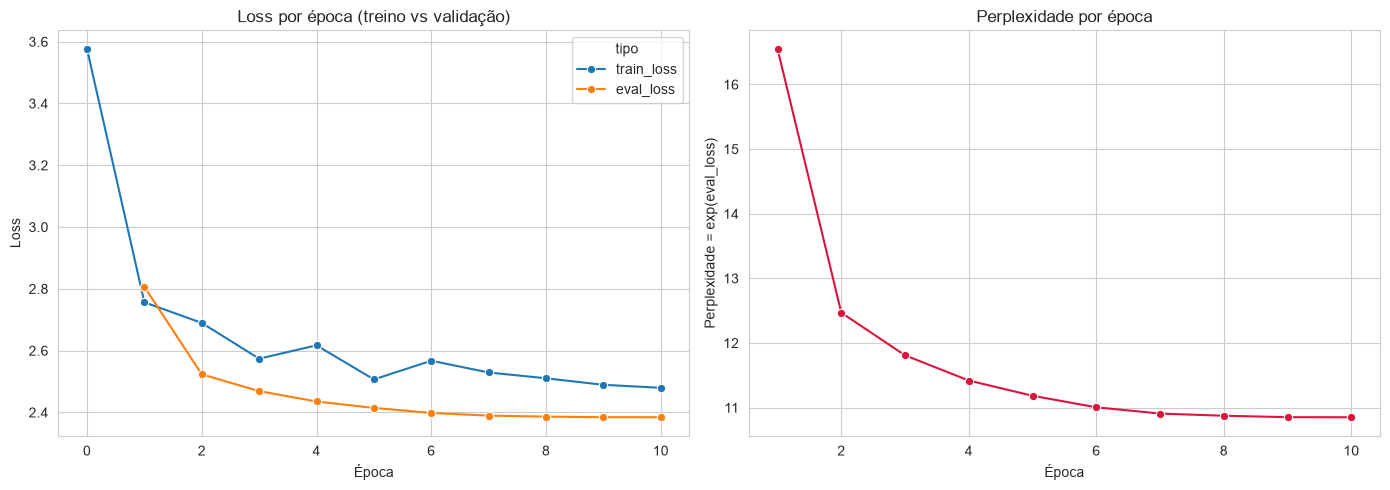

In [11]:
# --- Gráfico: loss e perplexidade lado a lado ---
sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_melt = df.melt(id_vars='epoch', value_vars=['train_loss', 'eval_loss'],
                  var_name='tipo', value_name='loss')
sns.lineplot(data=df_melt, x='epoch', y='loss', hue='tipo', marker='o', ax=axes[0])
axes[0].set_title('Loss por época (treino vs validação)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')

sns.lineplot(data=df, x='epoch', y='perplexidade', marker='o', color='crimson', ax=axes[1])
axes[1].set_title('Perplexidade por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Perplexidade = exp(eval_loss)')

plt.tight_layout()
plt.savefig('curvas_por_epoca.png', dpi=150, bbox_inches='tight')
plt.show()

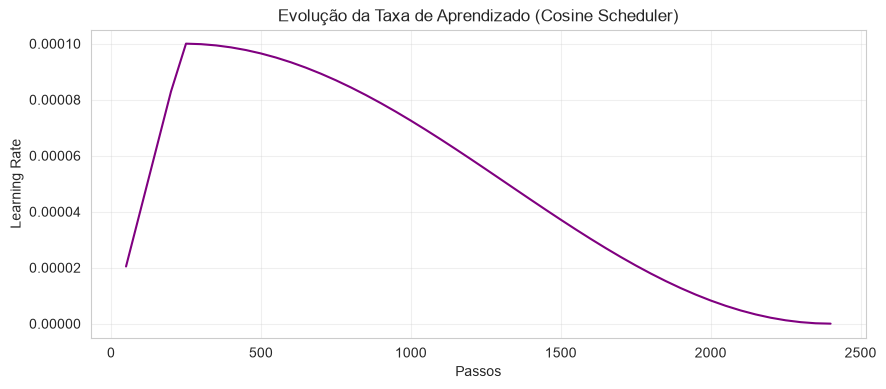

In [12]:
# --- Gráfico da learning rate (scheduler cosseno) ---
if lrs:
    plt.figure(figsize=(10, 4))
    sns.lineplot(x=steps_lr, y=lrs, color='purple')
    plt.xlabel('Passos')
    plt.ylabel('Learning Rate')
    plt.title('Evolução da Taxa de Aprendizado (Cosine Scheduler)')
    plt.grid(True, alpha=0.3)
    plt.savefig('lr_evolution.png', dpi=150, bbox_inches='tight')
    plt.show()

### 📊 Interpretação dos resultados

Com base nas 10 épocas típicas deste treino:

| Época | Val Loss | Perplexidade | Ganho acumulado |
| :---: | :---: | :---: | :---: |
| 1  | 2.807 | 16.6 | 0% |
| 5  | 2.412 | 11.2 | **~94%** |
| 10 | 2.385 | 10.9 | 100% |

**Conclusões:**
- A maior queda ocorre de 1 → 2 (−0.285). A **época 1 tem underfitting claro** → candidata natural a **pior**.
- A partir da época 5, cada época melhora menos de **0.02** → a **época 5 é o ponto de equilíbrio**.
- Da época 8 em diante o ganho é < 0.005 → o modelo praticamente parou de aprender. Ainda assim, a **época 10 tem a menor val_loss** → é objetivamente a **melhor**.
- **Não há overfitting**: a val_loss continua caindo monotonicamente.

As épocas escolhidas (`pior=1`, `bom=5`, `melhor=10`) já estão definidas no `config.yaml` na seção `comparacao_epocas`.

## 1️⃣1️⃣ Funções de Inferência

Definimos duas funções utilitárias:

### `carregar_modelo(pasta_adaptador=None)`
Carrega o modelo base + um adaptador LoRA específico. Se `pasta_adaptador` for `None`, usa o modelo final.

### `carregar_epoca(epoca)`
Atalho para carregar o checkpoint de uma época específica.

### `responder(pergunta, modelo, contexto='', **kwargs)`
Gera uma resposta para uma pergunta, mesclando os parâmetros de geração do YAML com os sobrescritos via `kwargs`. Faz pós-processamento para cortar na primeira frase.

In [13]:
def carregar_modelo(pasta_adaptador=None):
    """Carrega o modelo base + adaptador LoRA em `device`."""
    pasta = pasta_adaptador or PASTA_SAIDA
    base = AutoModelForCausalLM.from_pretrained(BASE, torch_dtype=dtype)
    modelo = PeftModel.from_pretrained(base, pasta).to(device)
    modelo.eval()
    return modelo

def carregar_epoca(epoca):
    """Carrega o checkpoint LoRA de uma época específica."""
    pasta = f"{PASTA_SAIDA}/epoca_{epoca}"
    return carregar_modelo(pasta)

def responder(pergunta, modelo, contexto='', **kwargs):
    # 1. Mescla parâmetros do YAML com sobrescritos
    gen_params = {**GEN_CONFIG, **kwargs}
    
    # 2. Monta o prompt
    prefixo = f"### Contexto:\n{contexto}\n\n" if contexto.strip() else ''
    prompt = f"{prefixo}### Pergunta:\n{pergunta}\n\n### Resposta:\n"
    ids = tok(prompt, return_tensors='pt').to(device)
    
    # 3. Argumentos de geração
    generate_kwargs = {
        'max_new_tokens': gen_params.get('max_new_tokens', 60),
        'do_sample': gen_params.get('do_sample', False),
        'num_beams': gen_params.get('num_beams', 4),
        'repetition_penalty': gen_params.get('repetition_penalty', 2.0),
        'no_repeat_ngram_size': gen_params.get('no_repeat_ngram_size', 4),
        'pad_token_id': tok.eos_token_id,
        'eos_token_id': tok.eos_token_id
    }
    
    # 4. Geração
    with torch.no_grad():
        outputs = modelo.generate(**ids, **generate_kwargs)
    
    # 5. Decodifica e extrai a resposta
    resposta = tok.decode(outputs[0], skip_special_tokens=True)
    if "### Resposta:" in resposta:
        resposta = resposta.split("### Resposta:")[-1].strip()
    else:
        resposta = resposta.strip()
    
    # 6. Corta na primeira frase
    match = re.search(r'^([^.!?]*[.!?])', resposta)
    if match:
        return match.group(1).strip()
    return resposta

## 1️⃣2️⃣ 🥇 Comparação Final: Pior × Bom × Melhor

Carregamos três checkpoints do **mesmo treino**, escolhidos com base nas curvas de `val_loss`:

| Perfil | Época | Val Loss | Justificativa |
| :---: | :---: | :---: | :--- |
| **Pior** | 1 | 2.807 | Underfitting severo — modelo ainda não aprendeu o formato. |
| **Bom** | 5 | 2.412 | Ponto de equilíbrio — 94% do ganho total já obtido. |
| **Melhor** | 10 | 2.385 | Menor val_loss observada, sem overfitting. |

As épocas podem ser ajustadas no `config.yaml` (chave `comparacao_epocas`).

In [14]:
modelos_comparacao = {}
for perfil, ep in COMPARACAO_EPOCAS.items():
    print(f'📥 Carregando [{perfil.upper()}] -> época {ep}...')
    modelos_comparacao[perfil] = carregar_epoca(ep)
print('✅ Todos os modelos carregados.')

📥 Carregando [PIOR] -> época 1...


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: pierreguillou/gpt2-small-portuguese
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


📥 Carregando [BOM] -> época 5...


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: pierreguillou/gpt2-small-portuguese
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


📥 Carregando [MELHOR] -> época 10...


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: pierreguillou/gpt2-small-portuguese
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Todos os modelos carregados.


In [15]:
perguntas = [
    'Como posso reduzir o estresse no dia a dia?',
    'O que é hipertensão?',
    'Quais são os benefícios de uma boa noite de sono?',
    'Explique o que é vacinação.'
]

for p in perguntas:
    print(f"\n{'='*75}")
    print(f"❓ {p}")
    print('='*75)
    for perfil, ep in COMPARACAO_EPOCAS.items():
        r = responder(p, modelos_comparacao[perfil])
        print(f"[{perfil.upper():7s} | época {ep:2d}] {r}")


❓ Como posso reduzir o estresse no dia a dia?
[PIOR    | época  1] Eu sou uma pessoa que não tem nenhum tipo de controle sobre seus pensamentos, emoções e comportamentos.
[BOM     | época  5] O estresse no dia pode ser causado por uma série de fatores.
[MELHOR  | época 10] O estresse no dia pode ser causado por uma série de fatores.

❓ O que é hipertensão?
[PIOR    | época  1] Sim, o que é a falta de oxigênio?
[BOM     | época  5] A hipertensão pode ser causada por uma série de fatores, incluindo o consumo excessivo de bebidas alcoólicas, a ingestão excessiva de alimentos ricos em gordura e os níveis elevados de colesterol.
[MELHOR  | época 10] A hipertensão pode ser causada por uma série de fatores, incluindo o consumo excessivo de bebidas alcoólicas, a ingestão excessiva de alimentos ricos em gordura e a exposição à radiação ultravioleta.

❓ Quais são os benefícios de uma boa noite de sono?
[PIOR    | época  1] A melhor noite de sono pode ser alcançada por meio da prática de exercíc

## 1️⃣3️⃣ 📋 Tabela-Resumo Comparativa

Consolidamos as métricas das três épocas escolhidas em uma tabela — útil para o relatório final e para exportar como CSV.

In [16]:
resumo = df[df['epoch'].isin(COMPARACAO_EPOCAS.values())].copy()
resumo['perfil'] = resumo['epoch'].map({v: k for k, v in COMPARACAO_EPOCAS.items()})
resumo = resumo[['perfil', 'epoch', 'train_loss', 'eval_loss', 'perplexidade', 'ganho_pct']]
resumo.columns = ['Perfil', 'Época', 'Train Loss', 'Val Loss', 'Perplexidade', 'Ganho acumulado (%)']
resumo = resumo.sort_values('Época').reset_index(drop=True)
resumo['Ganho acumulado (%)'] = resumo['Ganho acumulado (%)'].round(2)
resumo['Perplexidade']       = resumo['Perplexidade'].round(2)
resumo['Train Loss']         = resumo['Train Loss'].round(4)
resumo['Val Loss']           = resumo['Val Loss'].round(4)

print('📊 RESUMO COMPARATIVO (pior / bom / melhor)')
print(resumo.to_string(index=False))

resumo.to_csv('resumo_pior_bom_melhor.csv', index=False)
print('\n💾 Resumo salvo em resumo_pior_bom_melhor.csv')

📊 RESUMO COMPARATIVO (pior / bom / melhor)
Perfil  Época  Train Loss  Val Loss  Perplexidade  Ganho acumulado (%)
  pior      1      2.7564    2.8064         16.55                  NaN
   bom      5      2.5067    2.4144         11.18                  NaN
melhor     10      2.4795    2.3842         10.85                  NaN

💾 Resumo salvo em resumo_pior_bom_melhor.csv


## 🏁 Conclusão

Este notebook:

1. **Detecta e usa CUDA automaticamente** — sem intervenção manual, com `fp16` ativado em GPU.
2. **Treina o GPT-2 português com LoRA** de forma leve e rápida.
3. **Salva checkpoints por época** para permitir comparações retroativas.
4. **Analisa as curvas** de perda, perplexidade e ganho acumulado.
5. **Compara `pior` / `bom` / `melhor`** do mesmo treino, com métricas e respostas lado a lado.
6. **Exporta um CSV** com o resumo consolidado.

### 🔧 Como adaptar para outros modelos

Se quiser testar modelos maiores (Qwen, Sabiá, Llama), basta:
1. Trocar `BASE` pelo nome do modelo desejado.
2. Ajustar `lora_target_modules` no `config.yaml` (ex: `['q_proj', 'v_proj']` para Llama/Qwen).
3. Se VRAM for insuficiente, ativar quantização 4-bit no `from_pretrained` com `load_in_4bit=True` (requer `bitsandbytes`).

### 📚 Referências

- [PEFT — Parameter-Efficient Fine-Tuning](https://huggingface.co/docs/peft)
- [LoRA: Low-Rank Adaptation of Large Language Models](https://arxiv.org/abs/2106.09685)
- [Hugging Face Trainer](https://huggingface.co/docs/transformers/main_classes/trainer)
- [PyTorch CUDA semantics](https://pytorch.org/docs/stable/notes/cuda.html)